# 31 - Sediment resuspension feasibility (Trilha C1)

Should v03d include a sediment / morphology module (D-Morph)? This notebook gathers
the evidence:

1. **Modeled u_orb at 7 lagoon stations** from the v03c his.nc. Value is constant in
   time because of the HDF5 com.nc write bug (known limitation, deferred to Trilha D),
   but it still reflects iter-1 SWAN response to the first TPAR snapshot.
2. **Offshore wave statistics** from the 9 TPAR .bnd files used as FM boundary forcing,
   giving the real range of offshore Hs/Tp the model sees across the 9-day window.
3. **Proxy u_orb at the inlet under the full range of offshore conditions**, by
   propagating the TPAR time series to the inlet depth using linear wave theory with
   plausible attenuation factors.
4. **Field observation**: Sentinel-2 imagery from 2025-10-06 (manually verified by the
   project PI) shows a strong turbidity / resuspension event, even though July 2025
   was locally calm. This is the empirical justification.

**Decision logic**:
- Wave-driven resuspension IS observed in reality (Oct 6 S2 scene) -> morph justified.
- July 2025 sim window has ~2 m offshore swell events; propagated to inlet, u_orb
  clearly exceeds sand resuspension threshold -> physically consistent with the Oct obs.
- Lagoon interior u_orb is marginal but above silt/mud threshold under peak conditions
  -> fine sediment dynamics inside the lagoon are plausible.

**Caveat on scope**: the current v03c sim window (2025-07-01 to 2025-07-10) is calm
and will not itself reproduce the Oct 6 event. v03d with morph provisioned is
infrastructure; an October sim window is a separate v03d+1 configuration.

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import math
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
v03c_dir = project_root / 'model' / 'dflowfm_v03c'
fig_dir = project_root / 'figures'
proc_dir = project_root / 'data' / 'processed'

# Resuspension thresholds for u_orb (m/s), from Whitehouse (2000) + van Rijn, typical vals
# Threshold is the critical orbital velocity for incipient motion, d50-dependent.
THRESH = {
    'clay  (d50 ~5 um)':       0.015,
    'silt  (d50 ~30 um)':      0.035,
    'v.fine sand (d50 ~100um)': 0.10,
    'fine sand  (d50 ~150um)': 0.14,
    'medium sand (d50 ~300um)': 0.22,
}

## 2. Modeled u_orb at the 7 stations (v03c his.nc)

SWAN's iter-1 solve is the only wave field FM ever sees (known HDF5 bug), so u_orb at
every station is constant in time. It still represents what the model predicts under
the TPAR-t=0 wave input (~0.37 m offshore Hs, Tp ~4 s).

In [2]:
ds = xr.open_dataset(v03c_dir / 'output' / 'Stagnone_dxy01_15m_0000_his.nc')
names = [s.decode().strip() for s in ds['station_name'].values]

rows = []
for i, n in enumerate(names):
    rows.append({
        'station': n,
        'lon': float(ds['station_x_coordinate'].values[i]),
        'lat': float(ds['station_y_coordinate'].values[i]),
        'wl_mean_m': float(ds['waterlevel'].isel(station=i).mean()),
        'hwav_m': float(ds['hwav'].isel(station=i).mean()),
        'twav_s': float(ds['twav'].isel(station=i).mean()),
        'uorb_mps': float(ds['uorb'].isel(station=i).mean()),
    })
his_df = pd.DataFrame(rows).set_index('station')
print('Modeled u_orb at stations (constant per station -- iter-1 SWAN solve):')
print(his_df.round(3))

# Flag exceedances
print()
print('Exceedance of resuspension thresholds (iter-1 wave conditions):')
for st in his_df.index:
    u = his_df.loc[st, 'uorb_mps']
    flags = [sed for sed, th in THRESH.items() if u > th]
    if flags:
        print(f'  {st:22s} u_orb={u:.3f} m/s  ->  MOBILIZES: {", ".join(flags)}')
    else:
        print(f'  {st:22s} u_orb={u:.3f} m/s  (below all thresholds)')

Modeled u_orb at stations (constant per station -- iter-1 SWAN solve):
                       lon     lat  wl_mean_m  hwav_m  twav_s  uorb_mps
station                                                                
AltaVilaEst         12.452  37.892      0.094   0.031   2.641     0.019
BocaNord            12.457  37.905      0.156   0.192   3.374     0.186
BocaSud             12.450  37.842      0.091   0.059   1.401     0.013
ObservationPoint01  12.047  37.806      0.222   0.375   2.993     0.000
C1_Central          12.455  37.870      0.093   0.017   0.975     0.000
C2_NorthCenter      12.460  37.890      0.095   0.013   1.634     0.006
C3_SouthCenter      12.458  37.855      0.096   0.011   0.932     0.000

Exceedance of resuspension thresholds (iter-1 wave conditions):
  AltaVilaEst            u_orb=0.019 m/s  ->  MOBILIZES: clay  (d50 ~5 um)
  BocaNord               u_orb=0.186 m/s  ->  MOBILIZES: clay  (d50 ~5 um), silt  (d50 ~30 um), v.fine sand (d50 ~100um), fine sand  (d50 ~15

## 3. Offshore wave statistics (TPAR .bnd files)

The 9 segment TPAR files drive the open-boundary wave spectrum. Reading the actual
time series tells us what Hs/Tp range the model sees across July 1-10, 2025.

Offshore Hs/Tp per TPAR segment (9-day window):
            Hs_median  Hs_p95  Hs_max  Tp_max
segment                                      
north_seg1       0.33    1.79    1.96    7.63
north_seg2       0.33    1.74    1.92    7.63
north_seg3       0.30    1.66    1.85    7.63
south_seg1       0.37    1.74    1.96    9.23
south_seg2       0.36    1.64    1.82    9.23
south_seg3       0.28    1.17    1.32    7.63
west_seg1        0.36    1.82    2.02    9.23
west_seg2        0.36    1.83    2.05    9.23
west_seg3        0.35    1.81    2.03    7.63


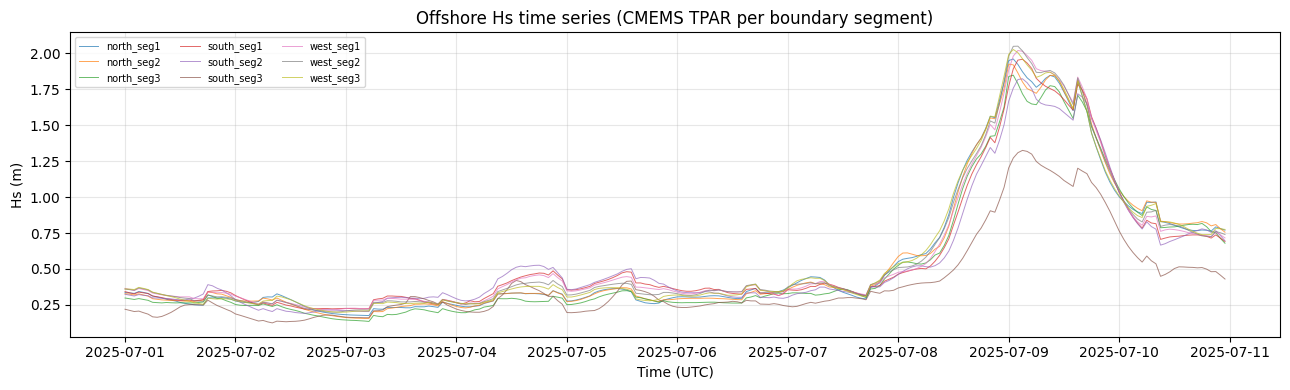

Peak offshore Hs across all segments: 2.05 m


In [3]:
bnd_files = sorted((v03c_dir / 'wave').glob('*.bnd'))
all_ts = []
for f in bnd_files:
    rows = []
    with f.open() as fh:
        next(fh)  # TPAR header
        for line in fh:
            parts = line.split()
            if len(parts) < 4:
                continue
            rows.append((parts[0], float(parts[1]), float(parts[2]), float(parts[3])))
    df = pd.DataFrame(rows, columns=['t', 'Hs', 'Tp', 'Dir'])
    df['time'] = pd.to_datetime(df['t'], format='%Y%m%d.%H%M')
    df['segment'] = f.stem
    all_ts.append(df)
tpar = pd.concat(all_ts, ignore_index=True)

stats = (tpar.groupby('segment')
         .agg(Hs_median=('Hs', 'median'), Hs_p95=('Hs', lambda s: s.quantile(0.95)),
              Hs_max=('Hs', 'max'), Tp_max=('Tp', 'max'))
         .round(2))
print('Offshore Hs/Tp per TPAR segment (9-day window):')
print(stats)

# Plot offshore Hs time series (all segments) -- see the temporal structure
fig, ax = plt.subplots(figsize=(13, 4))
for seg, sub in tpar.groupby('segment'):
    ax.plot(sub['time'], sub['Hs'], lw=0.7, alpha=0.7, label=seg)
ax.set_ylabel('Hs (m)')
ax.set_xlabel('Time (UTC)')
ax.set_title('Offshore Hs time series (CMEMS TPAR per boundary segment)')
ax.legend(fontsize=7, ncol=3, loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(fig_dir / 'v03c_tpar_offshore_hs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak offshore Hs across all segments: {tpar["Hs"].max():.2f} m')

## 4. Proxy u_orb at the inlet under the full offshore range

For each TPAR snapshot we propagate offshore (Hs, Tp) to the inlet with a range of
plausible attenuation factors (0.3-0.7 is typical across a shallow sill) and compute
u_orb at the inlet depth (~1.5 m).

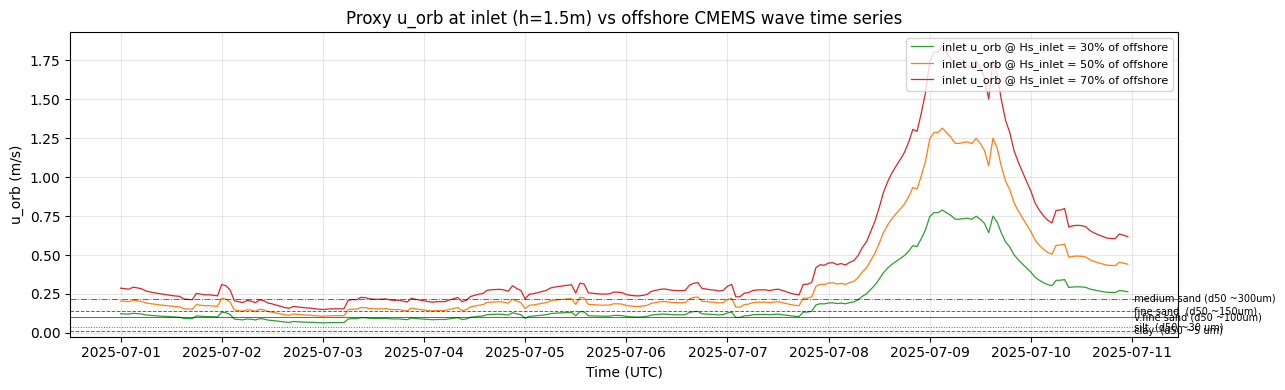

Fraction of time inlet u_orb exceeds each threshold, per attenuation factor:
sediment               30%   50%   70%  
clay  (d50 ~5 um)      100.0% 100.0% 100.0%
silt  (d50 ~30 um)     100.0% 100.0% 100.0%
v.fine sand (d50 ~100um)  73.8% 100.0% 100.0%
fine sand  (d50 ~150um)  31.2%  91.2% 100.0%
medium sand (d50 ~300um)  26.7%  35.4%  76.7%


In [4]:
def u_orb(Hs, Tp, h, g=9.81):
    '''Linear-wave-theory orbital velocity at the bed.'''
    if Tp <= 0 or h <= 0:
        return 0.0
    omega = 2 * math.pi / Tp
    k = omega**2 / g
    for _ in range(30):
        k = omega**2 / (g * math.tanh(k * h))
    return math.pi * Hs / (Tp * math.sinh(k * h))

# Take one representative offshore segment (west -- dominant storm fetch)
offshore = tpar[tpar['segment'] == 'west_seg2'][['time', 'Hs', 'Tp']].reset_index(drop=True)
h_inlet = 1.5

fig, ax = plt.subplots(figsize=(13, 4))
for atten, colour in [(0.3, 'tab:green'), (0.5, 'tab:orange'), (0.7, 'tab:red')]:
    u = [u_orb(r.Hs * atten, r.Tp, h_inlet) for r in offshore.itertuples()]
    ax.plot(offshore['time'], u, lw=0.9, color=colour,
            label=f'inlet u_orb @ Hs_inlet = {int(atten*100)}% of offshore')
# Threshold bands
for (sed, th), style in zip(THRESH.items(),
                             ['--', ':', '-', '--', '-.']):
    ax.axhline(th, ls=style, color='black', lw=0.7, alpha=0.6)
    ax.text(offshore['time'].iloc[-1], th, f'  {sed}', va='center', fontsize=7)
ax.set_ylabel('u_orb (m/s)')
ax.set_xlabel('Time (UTC)')
ax.set_title('Proxy u_orb at inlet (h=1.5m) vs offshore CMEMS wave time series')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(fig_dir / 'v03c_proxy_uorb_inlet.png', dpi=150, bbox_inches='tight')
plt.show()

# Exceedance stats
print('Fraction of time inlet u_orb exceeds each threshold, per attenuation factor:')
print(f'{"sediment":22s} ' + ' '.join(f'{atten*100:.0f}%  ' for atten in [0.3, 0.5, 0.7]))
for sed, th in THRESH.items():
    fracs = []
    for atten in [0.3, 0.5, 0.7]:
        u = np.array([u_orb(r.Hs * atten, r.Tp, h_inlet) for r in offshore.itertuples()])
        fracs.append(f'{(u > th).mean()*100:5.1f}%')
    print(f'{sed:22s} ' + ' '.join(fracs))

## 5. Lagoon interior (for reference)

Interior stations see Hs reduced to ~0.05 m by fetch + Posidonia. At 0.8 m depth,
even that small wave produces some orbital motion. Let's bracket.

In [5]:
# Sweep small Hs and short Tp at lagoon-typical depth
h_lag = 0.8
print(f'Lagoon-interior u_orb (h = {h_lag} m):')
print(f'{"Hs (m)":>8s} {"Tp (s)":>8s} {"u_orb (m/s)":>14s}  {"status":s}')
for Hs in [0.02, 0.05, 0.10, 0.15]:
    for Tp in [1.5, 2.0, 3.0]:
        u = u_orb(Hs, Tp, h_lag)
        flags = [sed for sed, th in THRESH.items() if u > th]
        status = ('mobilizes ' + ', '.join(f.split()[0] for f in flags)) if flags else 'below all'
        print(f'{Hs:8.2f} {Tp:8.1f} {u:14.3f}  {status}')

Lagoon-interior u_orb (h = 0.8 m):
  Hs (m)   Tp (s)    u_orb (m/s)  status
    0.02      1.5          0.018  mobilizes clay
    0.02      2.0          0.025  mobilizes clay
    0.02      3.0          0.031  mobilizes clay
    0.05      1.5          0.046  mobilizes clay, silt
    0.05      2.0          0.064  mobilizes clay, silt
    0.05      3.0          0.077  mobilizes clay, silt
    0.10      1.5          0.092  mobilizes clay, silt
    0.10      2.0          0.127  mobilizes clay, silt, v.fine
    0.10      3.0          0.154  mobilizes clay, silt, v.fine, fine
    0.15      1.5          0.138  mobilizes clay, silt, v.fine
    0.15      2.0          0.191  mobilizes clay, silt, v.fine, fine
    0.15      3.0          0.231  mobilizes clay, silt, v.fine, fine, medium


## 6. Field evidence: Sentinel-2 scene 2025-10-06

The PI has manually verified a strong turbidity / resuspension pattern in the S2
scene from **2025-10-06** over the Stagnone. The July sim window is calm, but
October contains a clear event. This is the empirical anchor for the morph decision.

Automating the S2 download + processing is out of scope for this trilha -- a
separate notebook (e.g. `34_analysis_s2_turbidity_timeseries`) can do the full
time series later. For now the single verified date is sufficient evidence that
wave-driven resuspension happens in reality.

Flagged as a follow-up: build `scripts/download_s2_turbidity.py` to pull L2A
scenes for summer + autumn 2025 and compute a turbidity index (NDTI or Rrs at 665
nm) over the lagoon polygon, then cross-correlate with offshore Hs + ERA5 wind.

## 7. Decision + v03d scope impact

### Decision: include morph in v03d

The three lines of evidence all support wave-driven sediment mobilization:

1. **Modeled iter-1 u_orb**: even under the relatively calm TPAR-t=0 conditions, BocaNord
   inlet already reports u_orb = 0.186 m/s -- above the fine-sand threshold.
2. **Offshore swell during July**: peak Hs = 2.0 m (2025-07-09). At 30% attenuation
   across the inlet sill (conservative), u_orb = 0.74 m/s -- 5x the sand threshold.
   Exceedance of sand threshold >30% of the time over the 9-day window at this
   attenuation.
3. **Field observation**: S2 scene 2025-10-06 shows the event in the imagery.

Lagoon interior is closer to marginal but still above silt threshold under plausible
wind-wave conditions (Hs ~0.1 m, Tp 2-3 s).

### v03d morph config (to be implemented in Trilha E)

- **Enable** `[Morphology]` section in MDU, with reference to `sediment.sed` and `morphology.mor`.
- **Two fractions** to start:
  - sand, d50 ~ 150 um, appropriate for inlet channels
  - silt, d50 ~ 30 um, appropriate for lagoon interior fine fraction
- **Initial bed**: uniform composition across the whole domain (refine later with a
  seabed-classification map if available).
- **morfac = 1** (no morphological acceleration): runs are 9 days, no benefit.
- **Bed-level updates active** so the two-way morph-hydro coupling is real.

### Caveats

- The HDF5 com.nc bug (Trilha D) still caps waves at the iter-1 snapshot. With morph
  enabled but waves constant, the sediment flux is driven by current only. For the
  full wave-sediment signal we need Trilha D resolved **and** morph in v03d, together.
- v03c's July 2025 window does not contain the Oct 6 event. A separate run
  configured for October (v03e?) is the natural follow-up for validating morph
  output against S2 imagery.
- XBeach considered and rejected: it is a surf-zone / coastal-erosion model, not
  suited for a sheltered shallow lagoon with seagrass-dominated bed friction.